<a href="https://colab.research.google.com/github/neurogomez/HWNI_Bootcamp-CompStatsMaterial/blob/main/HWNI_Quantitative_Bootcamp_Data_Analysis_and_Basic_Statistics_Day_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HWNI Bootcamp: Data Analysis and Basic Statistics

## 1. Conceptual Overview of Experiemental Data, Smpling Randomness and Probability

**Goal:** Explore properties of experimental data  including sampling, randomness and probability through a sample data set.  




## Introduction to Python

Python is a free open-source programming language that facilitates quantitative analysis of data. In the excersises below we will be using Python to explore real data, make plots and learn about some basic statistics concepts.

If you are unfamilar with Python or programming in generally, we recommend the following resources below:
- [Software Carpentry 1-day Python tutorial](https://swcarpentry.github.io/python-novice-inflammation/)
- [Free Edx course Using Python for Research](https://www.edx.org/course/using-python-for-research)
- [SciPy lexture notes  ( more in-depth intro)](https://scipy-lectures.org/)
- [Python Data Science Handbook ](https://jakevdp.github.io/PythonDataScienceHandbook/)


If you're coming from a Matlab background, you might be intersested in the following [cheat sheet](https://cheatsheets.quantecon.org/) and the book _[Neural Data Science](https://www.worldcat.org/title/neural-data-science-a-primer-with-matlab-and-python/oclc/973932708)_ with both Matlab and Python versions.

In [ ]:
#@title Import Packages
import numpy as np
import seaborn as sns # seaborn - easy plotting for statistical visualizations
import matplotlib.pyplot as plt
%matplotlib inline
import numpy.random as npr
import pandas as pd
from scipy import stats

### Excercise 1.1: Describing and Exploring Data

In this lab we will be looking at some electrophysiology data to explore the properties and challenges of working with real data such as sampling from a population, randomness and probability distributions.

In this exercise we explore data from an paper that explored differences in  excitatory-inhibitory (E/I) balance across various Autism Spectrum Disorder (ASD) mice models. In one of the experiments, L4-evoked feedforward excitatory currents were recored in L2/3 Pyramidal Neurons in mouse somatosensory cortex (S1). Representary EPSC traces are shown in the figure below along with the experimental set up.

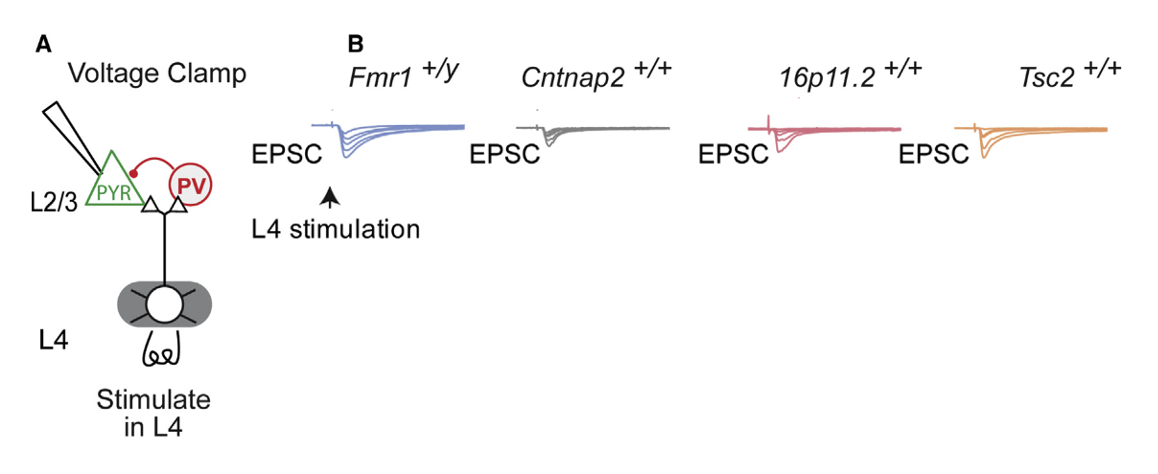

Figure adapted from _Antoine et al., 2019, Neuron101, 648–661_

The EPSC data set we will be using is stored in a [GitHub Respsository](https://kinsta.com/knowledgebase/what-is-github/). The data is organized into 2 columns containing evoked excitatory current amplitudes (pA) from L2/3 PYR cells of wildtype (wt) and ASD model mice. There are 4 data files with different sample sizes (N):
- [`EPSC_N20.csv`](https://raw.githubusercontent.com/neurogomez/HWNI_Bootcamp-CompStatsMaterial/main/EPSC_Data/EPSC_N20.csv)
- [`EPSC_N20_1.csv`](https://raw.githubusercontent.com/neurogomez/HWNI_Bootcamp-CompStatsMaterial/main/EPSC_Data/EPSC_N20_1.csv)
- [`EPSC_N100.csv`](https://raw.githubusercontent.com/neurogomez/HWNI_Bootcamp-CompStatsMaterial/main/EPSC_Data/EPSC_N100.csv)
- [`EPSC_N1000.csv`](https://raw.githubusercontent.com/neurogomez/HWNI_Bootcamp-CompStatsMaterial/main/EPSC_Data/EPSC_N1000.csv)
You can copy the link to the url embedded for each file above and read the file in as a [`pd.DataFrame`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html).




In [ ]:
#@title Helper Functions

def sample_currents(n):
  """Draw n excitatory current amplitude measurements from L2/3 PYR neurons in wild type and mutant.

  Args:
    n (number): number of samples to draw from distribution

  Returns
    wt (np.ndarray): Current Amplitude (pA) for WT
    mut (np.ndarray): Current Amplitude (pA) for Mutant
  """
  wt = npr.normal(200, 50, n)
  mutant = npr.normal(125, 50, n)
  data = {'Wild Type': wt, 'Mutant': mutant}
  df = pd.DataFrame(data)

  return df

1.  Generate a rug plot and histogram of excitatory current amplitudes using N=20 data points drawn using the `sample currents` function.

2. Try using different bin sizes (try `binwidth = 50, 10`) and different visualization parameters. Is the data well sampled? How do the histograms look with the different bin sizes? Undersampled, oversampled?


- _hint_: use [`sns.displot`](https://seaborn.pydata.org/generated/seaborn.displot.html#seaborn.displot) and [`sns.rugplot`](https://seaborn.pydata.org/generated/seaborn.rugplot.html)

In [ ]:
## Read the N=20 data set
df_currents_url = 'https://raw.githubusercontent.com/neurogomez/HWNI_Bootcamp-CompStatsMaterial/main/EPSC_Data/EPSC_N20.csv' # add the url of interest as a string
df_currents = pd.read_csv(df_currents_url, usecols = ['Wild Type', 'Mutant']) # read in csv as a data frame using pd
print(df_currents)

     Wild Type      Mutant
0   215.560449   87.146396
1   248.348583  173.873240
2   184.973681  112.657703
3   291.651134  122.846754
4   123.685875  221.096209
5   262.004281  154.806116
6   153.297330   72.385898
7   269.254598   22.634686
8   189.016995   87.454602
9   169.100964  121.284344
10  290.536426  138.611572
11  183.643235  113.646482
12  209.191345  127.131555
13  182.811041   61.067104
14  224.512981   54.524807
15  137.999917  121.471828
16  196.350402  188.236171
17  186.631604  152.100639
18  247.445156  153.439739
19  218.220121  184.184389


Text(0.5, 0, 'Excitatory Current Amplitude (pA)')

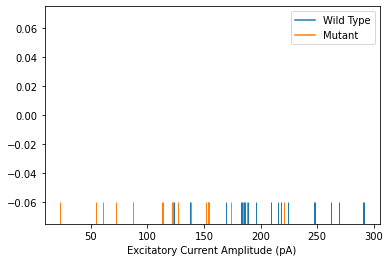

In [ ]:
## Plot a rugplot in the space below
sns.rugplot(data = df_currents, height=0.1)
plt.xlabel('Excitatory Current Amplitude (pA)')

Text(0.5, 6.79999999999999, 'Current Amplitude (pA)')

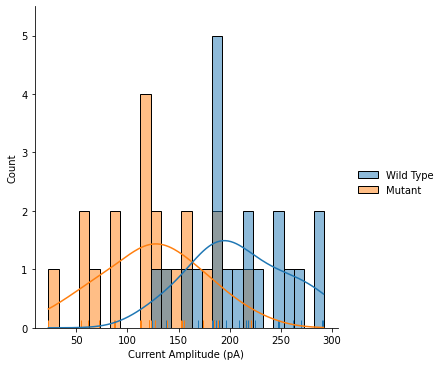

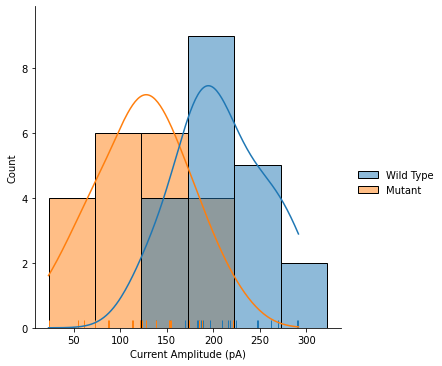

In [ ]:
## Plot a Histogram with biniwdth = 10 and binwidth = 50
sns.displot(data=df_currents, binwidth = 10, kde = 'True', rug = 'True', multiple='stack')
plt.xlabel('Current Amplitude (pA)')

sns.displot(data=df_currents, binwidth = 50, kde = 'True', rug = 'True', multiple='stack')
plt.xlabel('Current Amplitude (pA)')

3. Now try generating an additional 20 data points and compare how the distribution looks?

In [ ]:
## Read in the second N=20 data set
df_currents_url2 = 'https://raw.githubusercontent.com/neurogomez/HWNI_Bootcamp-CompStatsMaterial/main/EPSC_Data/EPSC_N20_1.csv' # add the url of interest as a string
df_currents2 = pd.read_csv(df_currents_url2, usecols = ['Wild Type', 'Mutant'])
print(df_currents2)

     Wild Type      Mutant
0   179.689704  218.256697
1   119.813207   40.377731
2   213.056067  180.889110
3   205.280843   79.704762
4   170.593194  131.744108
5   191.520236   34.660914
6   312.639174   86.425271
7   252.765255  128.877237
8   127.549350  177.447565
9   210.286102  103.800288
10  240.971514   56.566556
11  112.380932  148.478961
12  184.002391  116.607389
13  247.848183  184.836673
14  185.610471  154.670636
15  164.508591  139.035917
16  262.055008   96.479368
17   97.980812  181.106569
18  139.621625   81.227356
19  188.248831   71.565016


Text(0.5, 1.0, 'Repeated Experiement')

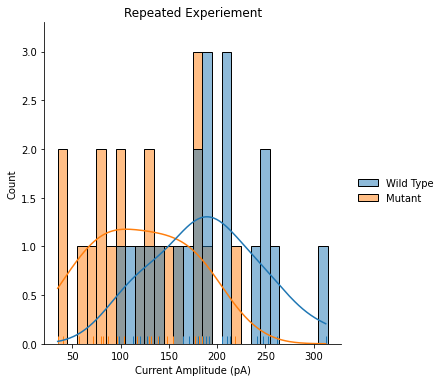

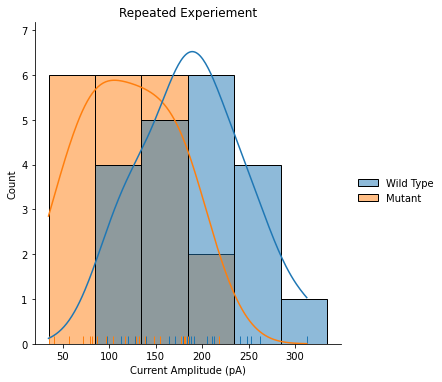

In [ ]:
## Histogram
sns.displot(data=df_currents2, binwidth = 10, kde = 'True', rug = 'True', multiple='stack')
plt.xlabel('Current Amplitude (pA)')
plt.title('Repeated Experiement')

sns.displot(data=df_currents2, binwidth = 50, kde = 'True', rug = 'True', multiple='stack')
plt.xlabel('Current Amplitude (pA)')
plt.title('Repeated Experiement')

Now that you have explored different bin widths, what bin width for N=20 gives the most reliable distribution?

4. Now let's increase our sample size and explore how the distribution changes as N increases. Try using _N=100_ and _1000_. What is the underlying distribution? Poisson, Binomial, Gaussian?

Text(0.5, 6.79999999999999, 'Current Amplitude (pA)')

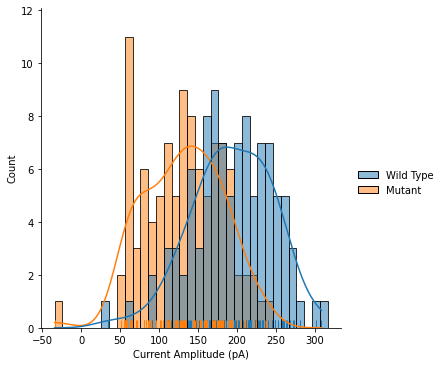

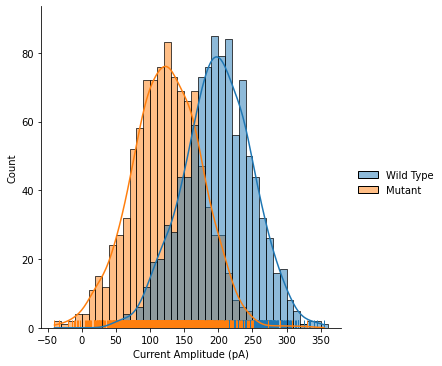

In [ ]:
df_currents_url_100 = 'https://raw.githubusercontent.com/neurogomez/HWNI_Bootcamp-CompStatsMaterial/main/EPSC_Data/EPSC_N100.csv' # add the url of interest as a string
df_currents_url_1000 = 'https://raw.githubusercontent.com/neurogomez/HWNI_Bootcamp-CompStatsMaterial/main/EPSC_Data/EPSC_N1000.csv' # add the url of interest as a string

df_currents_100 = pd.read_csv(df_currents_url_100, usecols = ['Wild Type', 'Mutant'])
df_currents_1000 = pd.read_csv(df_currents_url_1000, usecols = ['Wild Type', 'Mutant'])

## Histogram for 100
sns.displot(data=df_currents_100, binwidth = 10, kde = 'True', rug = 'True', multiple='stack')
plt.xlabel('Current Amplitude (pA)')

## Histogram for 1000
sns.displot(data=df_currents_1000, binwidth = 10, kde = 'True', rug = 'True', multiple='stack')
plt.xlabel('Current Amplitude (pA)')


5. After plotting the histogram for different _N_ sizees, describe the relationship between bin width, number of samples (N) and the reliability of the shape of the underlying distribution?

## 2. Data Visualization and Describing Data



### Example 2.1: Python Commands for 1D and 2D plots

Below are the python commands for plots commonly used to visualize 1-D and 2-D Paired and Unpaired Data

Text(0, 0.5, 'Current Amplitude (pA)')

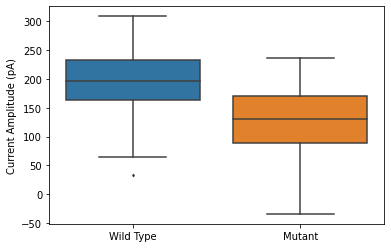

In [ ]:
## Boxplot
sns.boxplot(data=df_currents_100, fliersize=2)
plt.ylabel('Current Amplitude (pA)')

Text(0, 0.5, 'Current Amplitude (pA)')

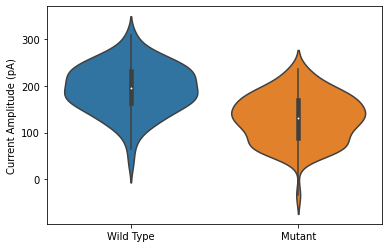

In [ ]:
## Violin Plot
sns.violinplot(data=df_currents_100, fliersize=5)
plt.ylabel('Current Amplitude (pA)')

Text(0.5, 6.79999999999999, 'Current Amplitude (pA)')

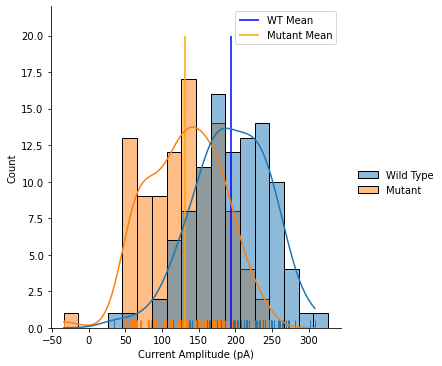

In [ ]:
## PDF Plot with Mean Sample Means
sns.displot(data=df_currents_100, binwidth = 20, kde = 'True', rug = 'True', multiple='stack', )
plt.vlines(np.mean(df_currents_100['Wild Type']), 0, 20, color = 'blue', label = 'WT Mean')
plt.vlines(np.mean(df_currents_100['Mutant']), 0, 20, color = 'orange', label = 'Mutant Mean')
plt.legend()
plt.xlabel('Current Amplitude (pA)')

## 3. Uncertainity, Confidence Intervals and Error Bars
As we saw in the previous section, we may want to infer properites of an entire population from the sample distribution we collect. The sample estimates properties of the population but always with some uncertainty. In this excerise we will explore how to plot measures of uncertainity like the Standard Error of the Mean (SEM) and Confidence Intervals (CI).


1. Using our previous example of L4-evoked feedforward excitatory currents from L2/3 PYR neurons in S1, we will try calculating the mean and sample standard deviations "by hand". We will then use that sample standard deviation to calcualte the SEM and Confidence Intervals



In [ ]:
## Calculate the Mean, Sample Standard Deviation and Standard Error of the Mean For N = 20

N = np.size(df_currents['Mutant'])

mean_wt = np.mean(df_currents['Wild Type'])
mean_mutant = np.mean(df_currents['Mutant'])

sstddev_wt = np.std(df_currents['Wild Type'],ddof=1)
sstddev_mutant = np.std(df_currents['Mutant'],ddof=1)

SEM_wt = sstddev_wt/np.sqrt(N)
SEM_mutant = sstddev_mutant/np.sqrt(N)

In [ ]:
## Calculate the 95% Confidence Intervals for the WT and Mutant For N = 20

import scipy.stats as st # we can use the library scipy.stats to get the z-score look up table

t_score95 = st.t.ppf(0.95, N) # find the t-value for 95% CI and the appropriate N value

CI_low_wt = mean_wt - t_score95*SEM_wt
CI_high_wt = mean_wt + t_score95*SEM_wt

CI_low_mutant = mean_mutant - t_score95*SEM_mutant
CI_high_mutant = mean_mutant + t_score95*SEM_mutant

In [ ]:
## Verify your CI calculation above with the `sms.DescrStatsW` function from the statsmodels library

import statsmodels.stats.api as sms # we can use the library stats models to verify our calculation of CIs

sms_CI_low_wt, sms_CI_high_wt = sms.DescrStatsW(df_currents['Wild Type']).tconfint_mean(alpha=0.05,  alternative='larger')
sms_CI_low_mutant, sms_CI_high_mutant = sms.DescrStatsW(df_currents['Mutant']).tconfint_mean(alpha=0.05,  alternative='larger')


/usr/local/lib/python3.7/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


2. Now putting all of our previous calculations together, make 3 plots of the WT and Mutant mean with Std Dev, CI and SEM errors.

Text(0.5, 1.0, 'Mutant Mean EPSC Amplitude')

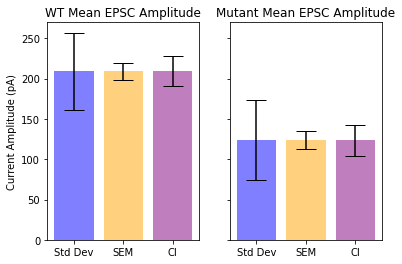

In [ ]:
## Plot the WT and Mutant Means with Std Dev, CI and SEM Error Bars
amp_wt_mean = [mean_wt, mean_wt, mean_wt]
amp_wt_labels = ['Std Dev', 'SEM', 'CI']
amp_wt_error = [sstddev_wt, SEM_wt,(CI_high_wt- CI_low_wt)/2]

amp_mutant_mean = [mean_mutant, mean_mutant, mean_mutant]
amp_mutant_labels = ['Std Dev', 'SEM', 'CI']
amp_mutant_error = [sstddev_mutant, SEM_mutant,(CI_high_mutant- CI_low_mutant)/2]

f, (ax1, ax2) = plt.subplots(1, 2, sharey=True)

# WT Plot
ax1.bar(np.arange(len(amp_wt_mean)), amp_wt_mean, yerr=amp_wt_error, align='center', color = ['blue', 'orange', 'purple'], alpha=0.5, ecolor='black', capsize=10)
ax1.set_xticks(np.arange(len(amp_wt_mean)))
ax1.set_xticklabels(amp_wt_labels)
ax1.set_ylabel('Current Amplitude (pA)')
ax1.set_title('WT Mean EPSC Amplitude')

# Mutant Plot
ax2.bar(np.arange(len(amp_mutant_mean)), amp_mutant_mean, yerr=amp_mutant_error, align='center', color = ['blue', 'orange', 'purple'], alpha=0.5, ecolor='black', capsize=10)
ax2.set_xticks(np.arange(len(amp_wt_mean)))
ax2.set_xticklabels(amp_wt_labels)
ax2.set_title('Mutant Mean EPSC Amplitude')


3. We sometimes see different types of error bars on plots in papers in presentations which can denot either standard deviation, SEM or CI. What is the interpration of each? What could be problematic about plotting just the mean +/- SEM?

_Note_: We did everything "by hand" here, however `sns.boxplot` and `sns.barplot` are seaborn functions that peform the calcualtions above and create beautiful, readable figures in one line.

Add line about how CI are calculated via bootstrapping


Text(0.5, 1.0, 'WT vs Mutant Mean EPSC Amplitude with 95% CI Error Bars')

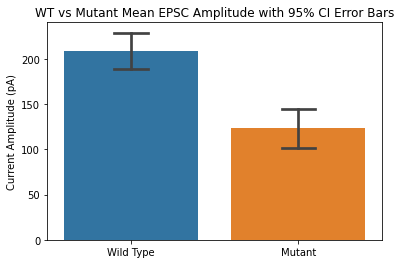

In [ ]:
sns.barplot(data = df_currents, capsize=.2)
plt.ylabel('Current Amplitude (pA)')
plt.title('WT vs Mutant Mean EPSC Amplitude with 95% CI Error Bars')

## 4. Hypothesis Testing: Comparing Groups

## 4. Hypothesis Testing by Bootstrapping

In this next example we will be looking at the firing rate of hippocampal neurons in mice exploring a cage that has no other mouse odor (no social context) or in which a mouse odor is present (social context). The question of interest is whether social context alters firing rate of these hippocampal neurons?

In [ ]:
## 1. Load in the social context experimental data
social_exp_url = 'https://raw.githubusercontent.com/neurogomez/HWNI_Bootcamp-CompStatsMaterial/main/Bootstrapping_Data/SocialExperimentData.csv' # add the url of interest as a string
df_socialexp = pd.read_csv(social_exp_url, usecols = ['NoSocial', 'Social'])
df_socialexp = df_socialexp.rename(columns={"NoSocial": "No Social Context", "Social": "Social Context"})
df_socialexp.head()

,No Social Context,Social Context
0,1.20,0.43
1,3.89,0.44
2,0.46,1.16
3,1.26,1.43
4,0.40,1.83


Text(0.5, 6.79999999999999, 'Firing Rate (Hz)')

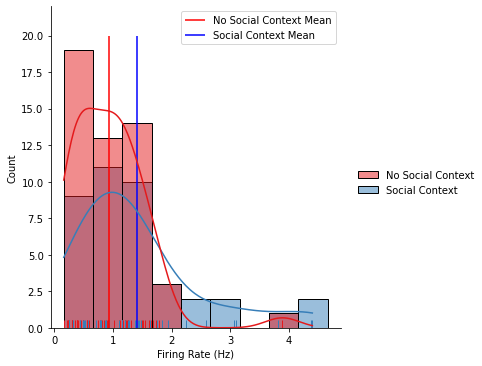

In [ ]:
# 2. Plot the overlapping PDFs of the Social vs Non-Social Context
sns.displot(data=df_socialexp, binwidth = 0.5, kde = 'True', rug = 'True', multiple='stack', palette='Set1')
plt.vlines(np.mean(df_socialexp['No Social Context']), 0, 20, color = 'red', label = 'No Social Context Mean')
plt.vlines(np.mean(df_socialexp['Social Context']), 0, 20, color = 'blue', label = 'Social Context Mean')
plt.legend()
plt.xlabel('Firing Rate (Hz)')

Q: What do you notice about this distribution compared to our previous EPSC example? Is the data normaly distributed? Can we use a t-test in this scenario?

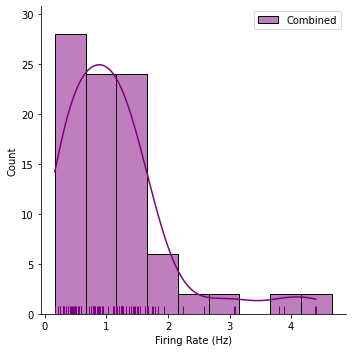

In [ ]:
## 3. Generate the combined distribution
df_combined = pd.DataFrame({'Combined':np.append(df_socialexp['No Social Context'], df_socialexp['Social Context'])}).dropna()
df_combined.head()

sns.displot(data=df_combined['Combined'], binwidth = 0.5, kde = 'True', rug = 'True', color = 'purple', label = 'Combined')
plt.xlabel('Firing Rate (Hz)')
plt.legend()

In [ ]:
## 4. Fill in the remainder of the boostrapping function
def boostrap_test(data_array, n_iterations):
  """Draw n excitatory current amplitude measurements from L2/3 PYR neurons in wild type and mutant.

  Args:
    data_array (array): pass the df['Column Name']
    n_iterations (integer): number of times to run the boostrapping test

  Returns
    null_pdf (array): the difference of means arrays between the randomly samples n=50 and n=40 data points
  """
  null_pdf = []
  for _ in range(n_iterations):
    non_social = np.random.choice(data_array, size=50)
    social = np.random.choice(data_array, size = 40 )
    null_pdf = np.append(null_pdf, np.mean(non_social) - np.mean(social))
  return null_pdf


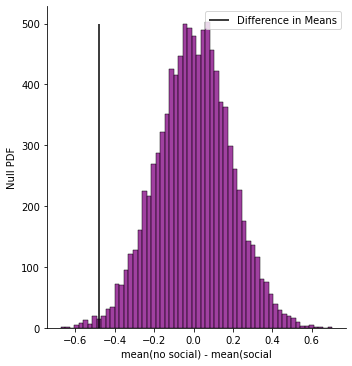

In [ ]:
## 5. Calculate the Difference in Means between the two samples
diff_mean = np.mean(df_socialexp['No Social Context']) - np.mean(df_socialexp['Social Context'])

## 6. Test your function above by plotting the null_pdf for n_iterations = 10000 and plotting the difference in means
null_pdf = boostrap_test(df_combined['Combined'], 10000)
sns.displot(null_pdf, color = 'purple')
plt.vlines(diff_mean, 0, 500, label = 'Difference in Means')
plt.xlabel('mean(no social) - mean(social')
plt.ylabel('Null PDF')
plt.legend()

Lastly, we would like to check into what precentile our *actual difference of sample means* falls into within the null pdf. To do so, we can use the function [`stats.percentileofscore`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.percentileofscore.html) from the package [scipy](https://docs.scipy.org/doc/scipy/reference/).



In [ ]:
## 7. Calculate the Corresponding p-value by computing the percentile rank of a score relative to a list of scores

p_value = stats.percentileofscore(null_pdf,diff_mean)/100
print(p_value)

0.0062

8. For an $\alpha$ = 0.05, is there a significant difference between both groups?